# Data Loading and Preprocessing

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import datetime as dt
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings('ignore')

### Load the dataset

In [45]:
df = pd.read_excel('Online_Retail.xlsx')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (541909, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

First 5 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B  

### Check for missing values

In [46]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


### Data cleaning

In [47]:
# Remove rows with missing customer IDs
df = df.dropna(subset=['CustomerID'])

In [48]:
# Convert CustomerID to string type
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

In [49]:
# Remove cancelled orders (those with InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [50]:
# Filter out returns or negative quantities
df = df[df['Quantity'] > 0]

In [51]:
# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

### Check for outliers or erroneous values

In [52]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
            Quantity                    InvoiceDate      UnitPrice  \
count  397924.000000                         397924  397924.000000   
mean       13.021823  2011-07-10 23:43:36.912475648       3.116174   
min         1.000000            2010-12-01 08:26:00       0.000000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 14:39:00       1.950000   
75%        12.000000            2011-10-20 14:33:00       3.750000   
max     80995.000000            2011-12-09 12:50:00    8142.750000   
std       180.420210                            NaN      22.096788   

          TotalPrice  
count  397924.000000  
mean       22.394749  
min         0.000000  
25%         4.680000  
50%        11.800000  
75%        19.800000  
max    168469.600000  
std       309.055588  


### Convert InvoiceDate to datetime format

In [53]:
if not pd.api.types.is_datetime64_any_dtype(df['InvoiceDate']):
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

### Calculate Recency, Frequency, Monetary (RFM) metrics

In [54]:


# Define the analysis date (using the most recent date in the dataset plus one day)
analysis_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Create a summary dataframe at customer level
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'TotalPrice': 'sum'  # Monetary
})
# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Display RFM summary
print("\nRFM Summary Statistics:")
print(rfm.describe())


RFM Summary Statistics:
           Recency    Frequency       Monetary
count  4339.000000  4339.000000    4339.000000
mean     92.518322     4.271952    2053.793018
std     100.009747     7.705493    8988.248381
min       1.000000     1.000000       0.000000
25%      18.000000     1.000000     307.245000
50%      51.000000     2.000000     674.450000
75%     142.000000     5.000000    1661.640000
max     374.000000   210.000000  280206.020000


### Remove any extreme outliers

In [55]:
# For example, cap monetary value at 99.5 percentile
monetary_cap = np.percentile(rfm['Monetary'], 99.5)
rfm.loc[rfm['Monetary'] > monetary_cap, 'Monetary'] = monetary_cap

# Log transform skewed variables (optional)
rfm_log = rfm.copy()
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])

# Scale the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm_log.columns)

# Display the scaled data
print("\nScaled RFM data (first 5 rows):")
print(rfm_scaled_df.head())


Scaled RFM data (first 5 rows):
             Recency  Frequency  Monetary
CustomerID                               
12346       2.334858  -0.955013  3.237967
12347      -0.905199   1.074523  1.426747
12348      -0.175186   0.386437  0.726086
12349      -0.735196  -0.955013  0.708201
12350       2.174855  -0.955013 -0.619556


# Exploratory Data Analysis and Visualization

### Recency distribution

Text(0.5, 1.0, 'Recency Distribution')

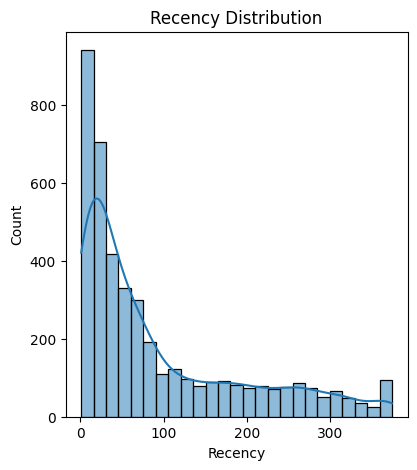

In [56]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], kde=True)
plt.title('Recency Distribution')

### Frequency distribution

Text(0.5, 1.0, 'Frequency Distribution')

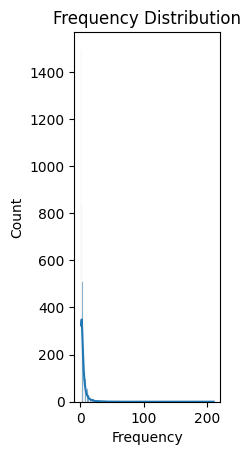

In [57]:
plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], kde=True)
plt.title('Frequency Distribution')

### Feature correlations

Text(0.5, 1.0, 'RFM Feature Correlations')

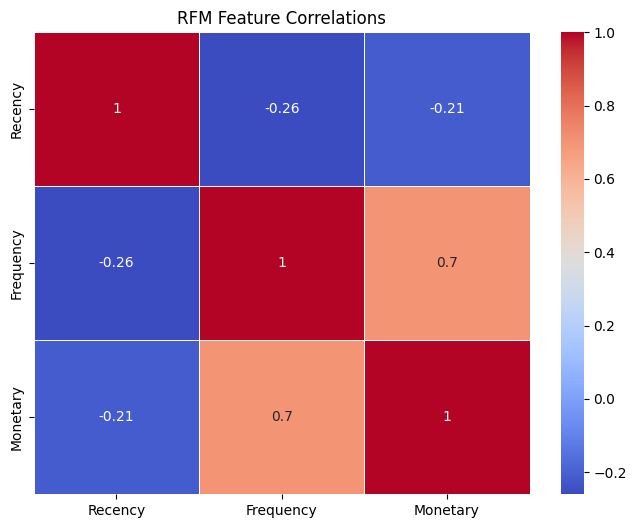

In [58]:

plt.figure(figsize=(8, 6))
sns.heatmap(rfm.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('RFM Feature Correlations')


### Pairplot to visualize relationships

Text(0.5, 1.02, 'Pairwise Relationships (Log-transformed)')

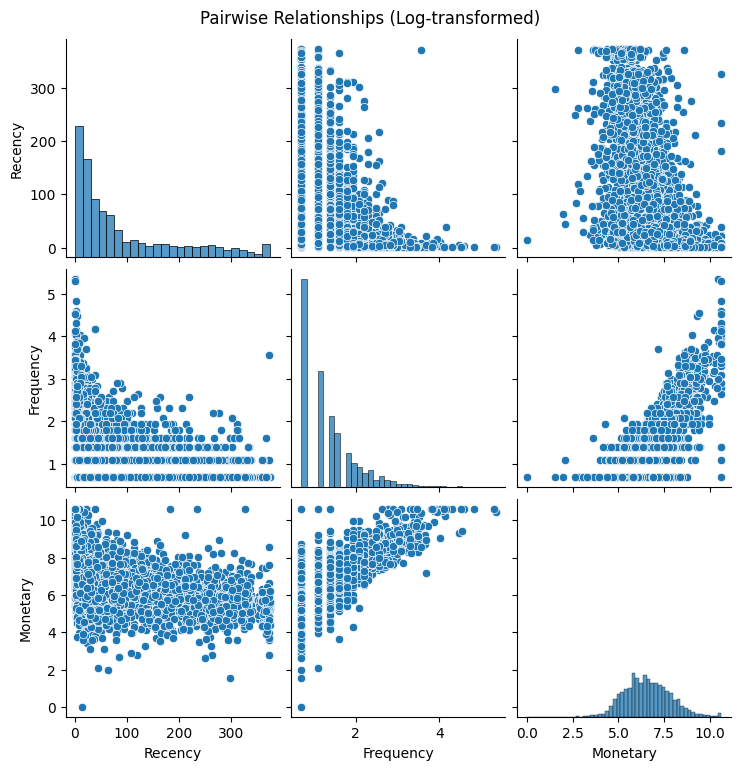

In [59]:
sns.pairplot(rfm_log)
plt.suptitle('Pairwise Relationships (Log-transformed)', y=1.02)

# Finding Optimal Number of Clusters

### Determine optimal number of clusters using the Elbow Method

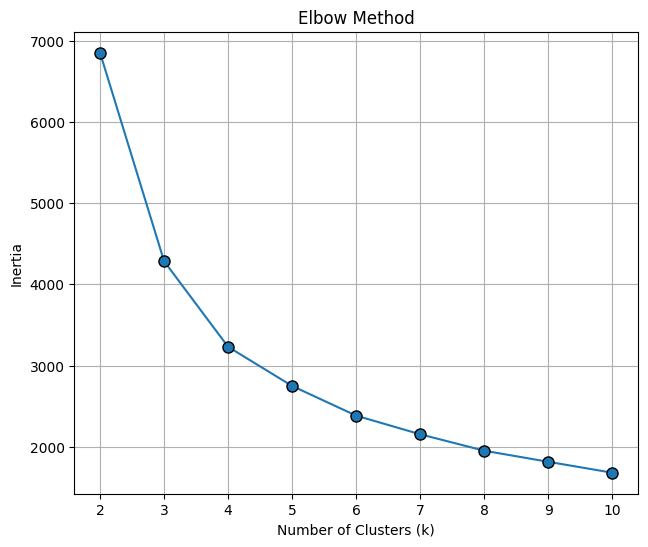

In [60]:

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plot Elbow Method results
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'o-', markersize=8, markeredgecolor='black')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)


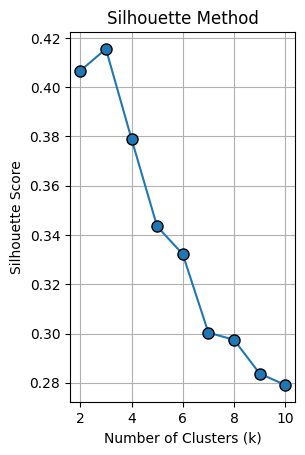

In [61]:
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'o-', markersize=8, markeredgecolor='black')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.grid(True)


In [62]:
optimal_k = 4

# Apply K-means with the optimal number of clusters

In [63]:

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Add cluster information to the original scaled dataframe
rfm_scaled_df['Cluster'] = rfm['Cluster']

# Calculate cluster centers
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                               columns=rfm.columns[:-1])

# Analyze clusters
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median', 'count'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median', 'sum']
}).round(2)

print("\nCluster Summary:")
print(cluster_summary)

# Calculate the percentage of customers in each cluster
cluster_counts = rfm['Cluster'].value_counts().sort_index()
cluster_percentages = (cluster_counts / cluster_counts.sum() * 100).round(2)

# Create a summary dataframe for visualization
cluster_analysis = pd.DataFrame({
    'Count': cluster_counts,
    'Percentage': cluster_percentages,
    'Avg_Recency': rfm.groupby('Cluster')['Recency'].mean().round(1),
    'Avg_Frequency': rfm.groupby('Cluster')['Frequency'].mean().round(1),
    'Avg_Monetary': rfm.groupby('Cluster')['Monetary'].mean().round(1),
    'Total_Revenue': rfm.groupby('Cluster')['Monetary'].sum().round(1)
})

print("\nCluster Analysis:")
print(cluster_analysis)



Cluster Summary:
        Recency              Frequency        Monetary                     
           mean median count      mean median     mean   median         sum
Cluster                                                                    
0        259.48  255.0   939      1.37    1.0   430.43   298.00   404172.34
1         46.15   31.0  1450      4.17    4.0  1589.35  1315.32  2304552.08
2         19.79   10.0   582     15.69   11.0  7521.50  4479.85  4377511.18
3         58.01   51.0  1368      1.51    1.0   381.29   342.08   521610.92

Cluster Analysis:
         Count  Percentage  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Cluster                                                                
0          939       21.64        259.5            1.4         430.4   
1         1450       33.42         46.1            4.2        1589.3   
2          582       13.41         19.8           15.7        7521.5   
3         1368       31.53         58.0            1.5         381.3   

### Visualize cluster distributions

Text(0, 0.5, 'Recency (days)')

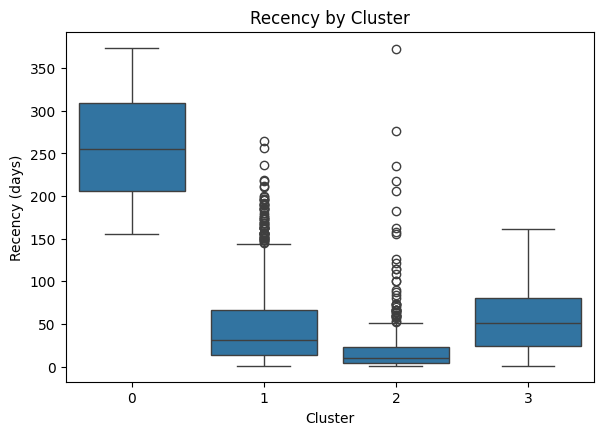

In [64]:

plt.figure(figsize=(15, 10))

# Recency by cluster
plt.subplot(2, 2, 1)
sns.boxplot(x='Cluster', y='Recency', data=rfm)
plt.title('Recency by Cluster')
plt.ylabel('Recency (days)')

### Frequency by cluster

Text(0, 0.5, 'Frequency (number of orders)')

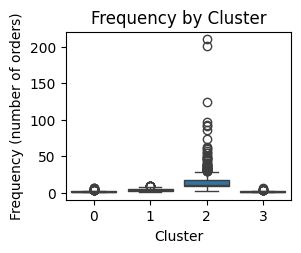

In [65]:
plt.subplot(2, 2, 2)
sns.boxplot(x='Cluster', y='Frequency', data=rfm)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency (number of orders)')

### Monetary by cluster

Text(0, 0.5, 'Monetary (total spend)')

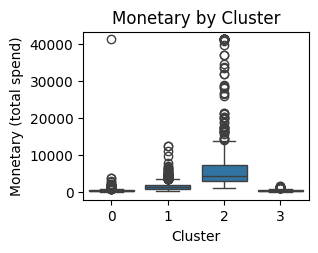

In [66]:

plt.subplot(2, 2, 3)
sns.boxplot(x='Cluster', y='Monetary', data=rfm)
plt.title('Monetary by Cluster')
plt.ylabel('Monetary (total spend)')

### Customer distribution by cluster

Text(0.5, 1.0, 'cluster_distributions')

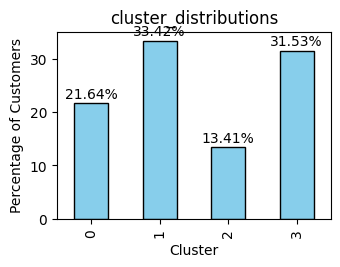

In [67]:

plt.subplot(2, 2, 4)
cluster_percentages.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Customer Distribution by Cluster')
plt.ylabel('Percentage of Customers')
plt.xlabel('Cluster')
for i, v in enumerate(cluster_percentages):
    plt.text(i, v + 1, f"{v}%", ha='center')

plt.tight_layout()
plt.title('cluster_distributions')

# Prepare data for radar chart

Text(0.5, 1.0, 'cluster_radar_chart')

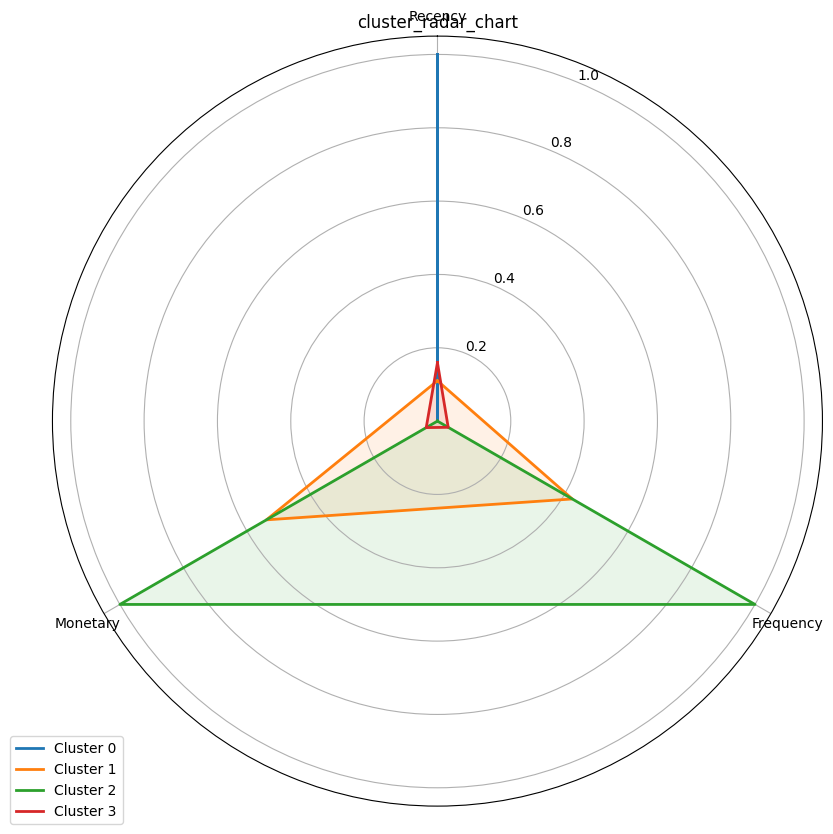

In [68]:
from math import pi


# Normalize cluster centers for radar chart
cluster_centers_normalized = cluster_centers.copy()
for col in cluster_centers.columns:
    min_val = cluster_centers[col].min()
    max_val = cluster_centers[col].max()
    cluster_centers_normalized[col] = (cluster_centers[col] - min_val) / (max_val - min_val)

# Create radar chart
categories = list(cluster_centers.columns)
N = len(categories)

# Create a figure
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Draw one axis per variable + add labels
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories)

for cluster in range(optimal_k):
    values = cluster_centers_normalized.iloc[cluster].values.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {cluster}')
    ax.fill(angles, values, alpha=0.1)

plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title('Radar Chart of Cluster Profiles', size=15, y=1.1)
plt.title('cluster_radar_chart')

# Customer Segmentation Interpretation

In [69]:
# Create a dictionary to store cluster characteristics
cluster_characteristics = {}
cluster_names = {}

# Define names for each cluster (example - adjust based on your actual results)
# This should be adjusted based on the actual cluster profiles you observe
for i in range(optimal_k):
    recency = rfm.groupby('Cluster').mean()['Recency'][i]
    frequency = rfm.groupby('Cluster').mean()['Frequency'][i]
    monetary = rfm.groupby('Cluster').mean()['Monetary'][i]
    
    # Create a profile based on RFM values
    characteristics = []
    
    # Recency interpretation
    if recency < rfm['Recency'].median() * 0.5:
        characteristics.append("Very recent shoppers")
    elif recency < rfm['Recency'].median():
        characteristics.append("Recent shoppers")
    elif recency < rfm['Recency'].median() * 2:
        characteristics.append("Moderate recency")
    else:
        characteristics.append("Inactive shoppers")
    
    # Frequency interpretation
    if frequency > rfm['Frequency'].quantile(0.75) * 1.5:
        characteristics.append("Very frequent shoppers")
    elif frequency > rfm['Frequency'].quantile(0.75):
        characteristics.append("Frequent shoppers")
    elif frequency > rfm['Frequency'].median():
        characteristics.append("Moderate frequency")
    else:
        characteristics.append("Infrequent shoppers")
    
    # Monetary interpretation
    if monetary > rfm['Monetary'].quantile(0.75) * 1.5:
        characteristics.append("High spenders")
    elif monetary > rfm['Monetary'].quantile(0.75):
        characteristics.append("Above average spenders")
    elif monetary > rfm['Monetary'].median():
        characteristics.append("Average spenders")
    else:
        characteristics.append("Low spenders")
    
    cluster_characteristics[i] = characteristics
    
    # Assign names based on combinations
    if "Very recent shoppers" in characteristics and "Very frequent shoppers" in characteristics and "High spenders" in characteristics:
        cluster_names[i] = "Champions"
    elif "Recent shoppers" in characteristics and "Frequent shoppers" in characteristics:
        cluster_names[i] = "Loyal Customers"
    elif "Inactive shoppers" in characteristics and "Infrequent shoppers" in characteristics:
        cluster_names[i] = "Dormant Customers"
    elif "Very recent shoppers" in characteristics and "Infrequent shoppers" in characteristics:
        cluster_names[i] = "New Customers"
    elif "Inactive shoppers" in characteristics and "Frequent shoppers" in characteristics:
        cluster_names[i] = "At Risk Customers"
    else:
        cluster_names[i] = f"Segment {i}"

# Print cluster interpretations
print("\nCluster Interpretations:")
for cluster, characteristics in cluster_characteristics.items():
    print(f"Cluster {cluster} ({cluster_names[cluster]}):")
    for characteristic in characteristics:
        print(f"  - {characteristic}")
    print(f"  - Represents {cluster_percentages[cluster]}% of customers")
    print()

# Export final results to CSV for further analysis
rfm.reset_index().to_csv('customer_segments.csv', index=False)
print("Customer segmentation complete. Results saved to customer_segments.csv")



Cluster Interpretations:
Cluster 0 (Dormant Customers):
  - Inactive shoppers
  - Infrequent shoppers
  - Low spenders
  - Represents 21.64% of customers

Cluster 1 (Segment 1):
  - Recent shoppers
  - Moderate frequency
  - Average spenders
  - Represents 33.42% of customers

Cluster 2 (Champions):
  - Very recent shoppers
  - Very frequent shoppers
  - High spenders
  - Represents 13.41% of customers

Cluster 3 (Segment 3):
  - Moderate recency
  - Infrequent shoppers
  - Low spenders
  - Represents 31.53% of customers

Customer segmentation complete. Results saved to customer_segments.csv


# Target Marketing Strategies

In [70]:
# Create a dataframe with marketing strategy recommendations
strategies = pd.DataFrame({
    'Cluster': list(cluster_names.keys()),
    'Segment_Name': list(cluster_names.values()),
    'Percentage': [cluster_percentages[i] for i in cluster_names.keys()],
    'Average_Recency': [rfm.groupby('Cluster').mean()['Recency'][i] for i in cluster_names.keys()],
    'Average_Frequency': [rfm.groupby('Cluster').mean()['Frequency'][i] for i in cluster_names.keys()],
    'Average_Monetary': [rfm.groupby('Cluster').mean()['Monetary'][i] for i in cluster_names.keys()]
})

# Add marketing recommendations based on segment names
marketing_strategies = []
for segment in strategies['Segment_Name']:
    if segment == "Champions":
        marketing_strategies.append("Reward programs, exclusive previews of new products, seek referrals")
    elif segment == "Loyal Customers":
        marketing_strategies.append("Upsell higher value products, engagement programs, limited time offers")
    elif segment == "Dormant Customers":
        marketing_strategies.append("Reactivation campaigns, surveys to understand churn reasons, win-back incentives")
    elif segment == "New Customers":
        marketing_strategies.append("Welcome series, education on product range, early retention offers")
    elif segment == "At Risk Customers":
        marketing_strategies.append("Personalized recommendations, special renewal offers, satisfaction surveys")
    else:
        marketing_strategies.append("Segment-specific targeted campaigns")

strategies['Recommended_Marketing'] = marketing_strategies

# Print marketing strategies
print("\nRecommended Marketing Strategies:")
print(strategies[['Segment_Name', 'Percentage', 'Recommended_Marketing']])

# Export marketing strategies to CSV
strategies.to_csv('marketing_strategies.csv', index=False)
print("Marketing strategies saved to marketing_strategies.csv")

print("\nAnalysis complete. Check the generated visualization files for insights.")



Recommended Marketing Strategies:
        Segment_Name  Percentage  \
0  Dormant Customers       21.64   
1          Segment 1       33.42   
2          Champions       13.41   
3          Segment 3       31.53   

                               Recommended_Marketing  
0  Reactivation campaigns, surveys to understand ...  
1                Segment-specific targeted campaigns  
2  Reward programs, exclusive previews of new pro...  
3                Segment-specific targeted campaigns  
Marketing strategies saved to marketing_strategies.csv

Analysis complete. Check the generated visualization files for insights.


# Time Series Analysis

Time series analysis complete. Check monthly_revenue_by_segment.png for trends.


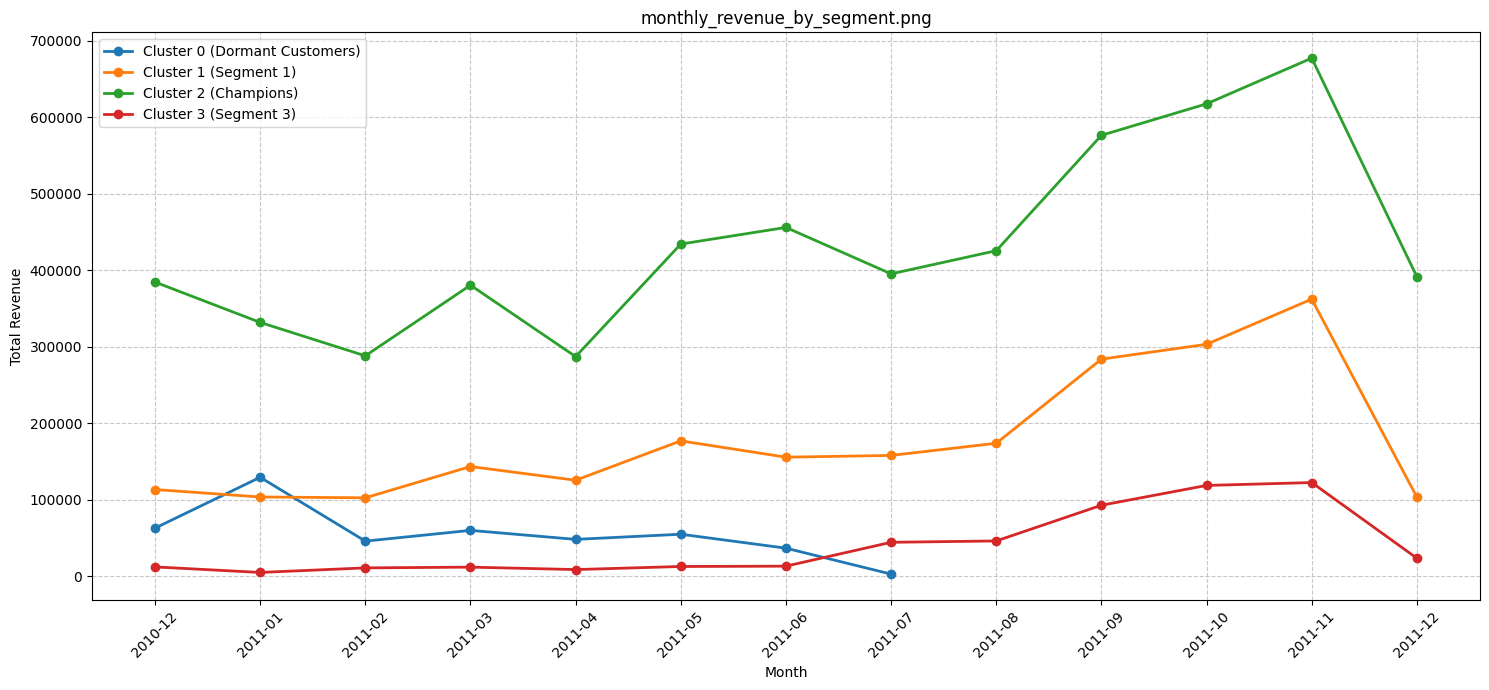

In [71]:
# Time-based analysis to see how customer behavior changes over time
temporal_analysis = df.copy()
temporal_analysis['Year-Month'] = temporal_analysis['InvoiceDate'].dt.to_period('M')

# Add cluster information
temporal_analysis = temporal_analysis.merge(
    rfm[['Cluster']].reset_index(), 
    on='CustomerID', 
    how='inner'
)

# Monthly revenue by cluster
monthly_revenue = temporal_analysis.groupby(['Year-Month', 'Cluster']).agg({
    'TotalPrice': 'sum'
}).reset_index()

# Pivot for plotting
monthly_pivot = monthly_revenue.pivot(index='Year-Month', columns='Cluster', values='TotalPrice')

# Plot monthly revenue trends by cluster
plt.figure(figsize=(15, 7))
for cluster in range(optimal_k):
    plt.plot(
        [str(x) for x in monthly_pivot.index], 
        monthly_pivot[cluster], 
        marker='o', 
        linewidth=2, 
        label=f"Cluster {cluster} ({cluster_names[cluster]})"
    )

plt.title('Monthly Revenue by Customer Segment')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.title('monthly_revenue_by_segment.png')

print("Time series analysis complete. Check monthly_revenue_by_segment.png for trends.")
